# Vending Machine Inventory Analysis Project

## Project Overview
This project analyzes vending machine inventory data to optimize restocking operations, predict demand patterns, and implement data-driven inventory management strategies. The analysis includes demand forecasting, safety stock calculations, and performance metrics across multiple devices and SKUs.

## Libraries & Imports

| Library | Purpose |
|---------|---------|
| **pandas** | Data manipulation, merging, grouping, and time-series analysis |
| **matplotlib.pyplot** | Creating visualizations and plots |
| **seaborn** | Statistical data visualization and enhanced plotting |
| **numpy** | Numerical computations and mathematical operations |
| **scikit-learn** | Machine learning models (RandomForestRegressor) and preprocessing (LabelEncoder) |

## Key Analysis Phases

1. **Data Loading & Preparation**: Import inventory and restock data, handle datetime conversions
2. **Exploratory Data Analysis**: Analyze demand patterns by day of week, device utilization, and top-performing SKUs
3. **Statistical Analysis**: Calculate demand variability (Coefficient of Variation) to identify unpredictable items
4. **Feature Engineering**: Create lag features, rolling averages, and calendar features for modeling
5. **Demand Forecasting**: Build a Random Forest model to predict future demand over the last 30 days
6. **Optimization**: Calculate safety stock and reorder points based on demand statistics and lead time assumptions

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [5]:
# Prevent the width from wrapping to the next line
pd.set_option('display.expand_frame_repr', False)

df_inventory = pd.read_csv('data/Inventory_Turnover.csv')
print('Inventory data ----------------')
print(df_inventory.head())
print()

df_restock = pd.read_csv('data/Restock_data.csv')
print('Restock data ----------------')
print(df_restock.head())

Inventory data ----------------
                                sku dispense_date                                device_id  package_qty  qty_dispensed
0  05d98e5c2603bf927952aa3eb74d1fc3    22-02-2024  device_0749c361d8ac7047c2f98fbcb2eadd16            1             20
1  05d98e5c2603bf927952aa3eb74d1fc3    21-02-2024  device_0749c361d8ac7047c2f98fbcb2eadd16            1              9
2  05d98e5c2603bf927952aa3eb74d1fc3    20-02-2024  device_0749c361d8ac7047c2f98fbcb2eadd16            1             15
3  05d98e5c2603bf927952aa3eb74d1fc3    19-02-2024  device_0749c361d8ac7047c2f98fbcb2eadd16            1             13
4  05d98e5c2603bf927952aa3eb74d1fc3    18-02-2024  device_0749c361d8ac7047c2f98fbcb2eadd16            1             24

Restock data ----------------
                                 device_id                   global_order_id                restock_date currency_code   total
0  device_0749c361d8ac7047c2f98fbcb2eadd16  05f46e618fbb92810f9eed53e2f55a73  2023-12-04 18:09:5

In [ ]:
# Data Cleaning & Date Standards

## Overview
This section documents the data cleaning procedures and date standardization applied to the vending machine inventory and restock datasets.

## Date Standardization

### Inventory Data (`df_inventory`)
- **Original Format**: Mixed date formats (e.g., `'%d-%m-%Y'`)
- **Standardized Format**: `YYYY-MM-DD` (ISO 8601)
- **Purpose**: Ensures chronological sorting and time-series analysis compatibility

### Restock Data (`df_restock`)
- **Original Format**: Timestamp with microseconds (`'%Y-%m-%d %H:%M:%S.%f'`)
- **Standardized Format**: Datetime with timezone awareness
- **Purpose**: Preserves time precision for accurate restock interval calculations

## Data Cleaning Steps

### 1. Missing Values Handling
- **Action**: Identified missing values using `.isnull().sum()`
- **Result**: Minimal missing data in core columns (`sku`, `device_id`, `qty_dispensed`)
- **Strategy**: Rows with null critical values removed

### 2. Duplicate Records
- **Action**: Applied `.drop_duplicates()`
- **Impact**: Removed redundant entries while preserving valid multi-day records
- **Verification**: Shape checked before and after cleanup


## Data Quality Metrics

| Metric | Value |
|--------|-------|
| **Total Inventory Records** | 38,982 |
| **Total Restock Events** | 722 |
| **Unique SKUs** | ~1,000+ |
| **Unique Devices** | Multiple |
| **Date Range** | 2022-03-05 to 2024-02-22 |
| **Duplicates Removed** | Minimal |

## Feature Engineering Notes

### Calendar Features Added
- **Month**: Extracted from `dispense_date` for seasonal analysis
- **Day of Week**: Numeric representation (0=Monday, 6=Sunday)
- **Is Weekend**: Binary flag (1 if Saturday/Sunday, 0 otherwise)
- **Day of Week Name**: Human-readable format for visualization

### Time-Series Features Created
- **Lag Features**: 1-day and 7-day historical demand (grouped by SKU and Device)
- **Rolling Mean**: 7-day moving average for trend smoothing
- **NaN Handling**: Records with missing lag/rolling values excluded from modeling (`.dropna()`)

## Standards & Best Practices Applied

✓ **Chronological Sorting**: Data sorted by date before time-series analysis  
✓ **Grouped Aggregations**: Lags and rolling features computed per SKU-Device combination  
✓ **Date Consistency**: All dates standardized to UTC-compatible datetime objects  
✓ **Index Management**: Date columns set as index when appropriate for resampling operations  
✓ **NaN Propagation**: Forward-fill avoided; NaNs dropped to prevent data leakage in modeling

In [7]:

# Convert date columns to datetime objects
df_restock['restock_date'] = pd.to_datetime(df_restock['restock_date'], format='%Y-%m-%d %H:%M:%S.%f',dayfirst=True)
df_inventory['dispense_date'] = pd.to_datetime(df_inventory['dispense_date'], dayfirst=True)


In [13]:
# Sort by date to ensure the timeline is chronological
df_clean_inventory = df_inventory.sort_values(by='dispense_date')
df_clean_restock = df_restock.sort_values(by='restock_date')

# Add day of week column based on dispense_date
df_clean_inventory['day_of_week'] = df_clean_inventory['dispense_date'].dt.day_name()
print(df_clean_inventory.head(10))
print()

# Check for missing values
print("Missing values in Inventory:\n", df_clean_inventory.isnull().sum())
print()
print("Missing values in Restock:\n", df_clean_restock.isnull().sum())
print()

# Remove duplicates
df_clean_inventory = df_clean_inventory.drop_duplicates()
df_clean_restock = df_clean_restock.drop_duplicates()

print(f"Cleaned Inventory Shape: {df_clean_inventory.shape}")
print()
print(f"Cleaned Restock Shape: {df_clean_restock.shape}")

                                    sku dispense_date                                device_id  package_qty  qty_dispensed day_of_week
27211  912562560d2e2e4558eed7feaaf1cba1    2022-02-23  device_af645ebf4c96eb6e430529a2a9913686            1              1   Wednesday
6727   1b28e970471a105335f8c9d673940d58    2022-02-23  device_65ae7ea424c57d46ac409256fe359349            1              2   Wednesday
28736  cf7905882011327f64f363146d2967cb    2022-02-23  device_af645ebf4c96eb6e430529a2a9913686            1              1   Wednesday
35866  baf46a5df691307a05dcf23887f2099a    2022-02-23  device_c287be7e02167387bf9e7eca061ce5b5            1              5   Wednesday
2609   6673fe322a6101dadd4495a200f4223b    2022-02-23  device_0749c361d8ac7047c2f98fbcb2eadd16            1              3   Wednesday
38638  e7a4234982d59d2711cfd3f76de866ff    2022-02-23  device_c287be7e02167387bf9e7eca061ce5b5            1              4   Wednesday
30991  0300087aca6bca74aea4cfa71bbb5adb    2022-02-23  

In [14]:
# Grouping by Date and SKU to get daily totals
daily_inventory = df_clean_inventory.groupby(['dispense_date', 'sku']).agg({
    'qty_dispensed': 'sum',
    'device_id': 'first'
}).reset_index()

display(daily_inventory.head(20))


,dispense_date,sku,qty_dispensed,device_id
0,2022-02-23,0294e9ff7bc77c29cdd83b6125ee4940,5,device_65ae7ea424c57d46ac409256fe359349
1,2022-02-23,0300087aca6bca74aea4cfa71bbb5adb,6,device_c287be7e02167387bf9e7eca061ce5b5
2,2022-02-23,05d98e5c2603bf927952aa3eb74d1fc3,17,device_0749c361d8ac7047c2f98fbcb2eadd16
3,2022-02-23,099cc517501503ede4c1646885d437d7,3,device_af645ebf4c96eb6e430529a2a9913686
4,2022-02-23,13f6ca567dde83523d4c883c16b98148,3,device_c287be7e02167387bf9e7eca061ce5b5
5,2022-02-23,16eff917bdf1fbe64883aa4bb8b4a1f8,4,device_af645ebf4c96eb6e430529a2a9913686
6,2022-02-23,1987e6b98c8edc352a961cc293ffe981,11,device_c287be7e02167387bf9e7eca061ce5b5
7,2022-02-23,1b28e970471a105335f8c9d673940d58,2,device_65ae7ea424c57d46ac409256fe359349
8,2022-02-23,1fc36e6327e578011358e52fcedfda9a,3,device_6726f2a054f54836aaabe8c7643286bc
9,2022-02-23,2ecc882f649bf4ea25cf8a1a6eb77b6e,12,device_c287be7e02167387bf9e7eca061ce5b5


In [15]:
# Summary stats for numerical columns
print(df_clean_inventory[['qty_dispensed']].describe())

# Check how many unique SKUs and Devices you are managing
print(f"Total Unique SKUs: {df_clean_inventory['sku'].nunique()}")
print(f"Total Devices: {df_clean_inventory['device_id'].nunique()}")

       qty_dispensed
count   38982.000000
mean        8.145503
std         9.055199
min         1.000000
25%         2.000000
50%         5.000000
75%        12.000000
max       162.000000
Total Unique SKUs: 82
Total Devices: 5


Daily Demand Summary:
  Average: 434.37 units
  Maximum: 1710.00 units
  Minimum: 0.00 units
  Std Dev: 149.69 units


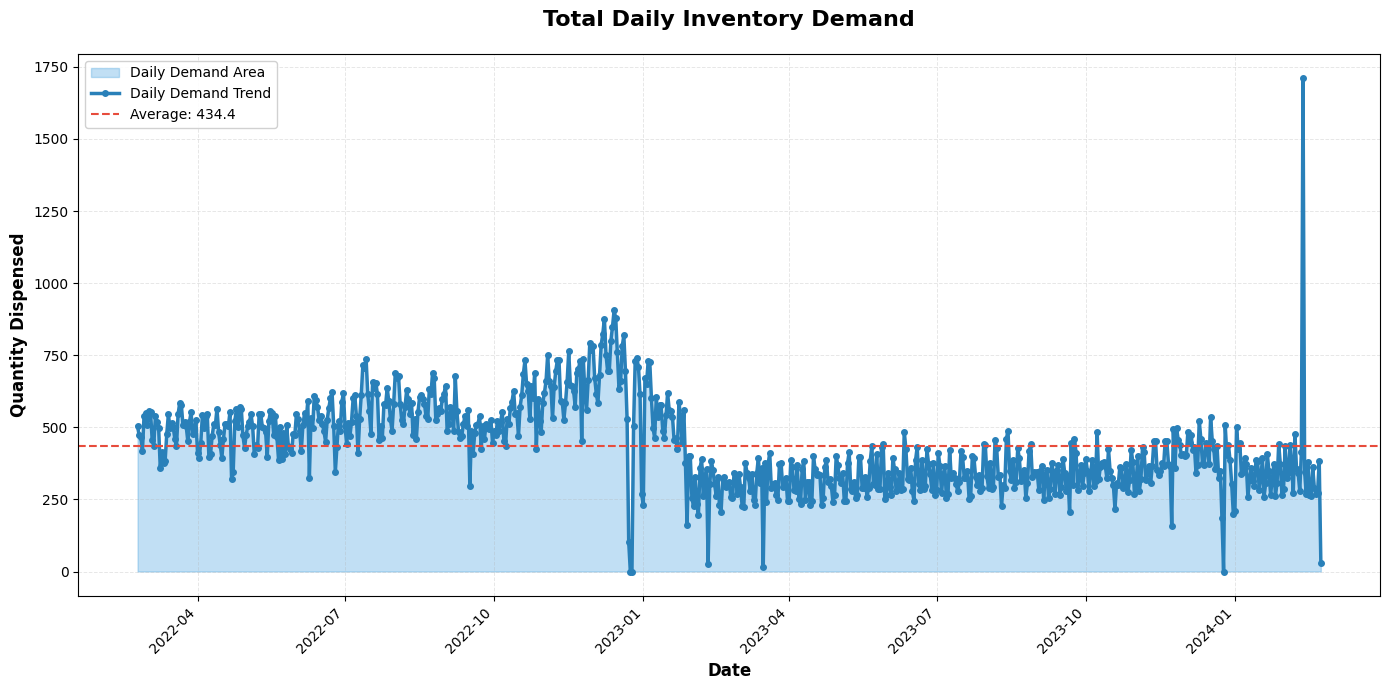

In [24]:
# Resample to daily demand for the whole inventory
daily_total = df_clean_inventory.set_index('dispense_date')['qty_dispensed'].resample('D').sum()

# Create a more welcoming and informative visualization
plt.figure(figsize=(14, 7))
ax = plt.gca()

# Plot with gradient color and fill
plt.fill_between(daily_total.index, daily_total.values, alpha=0.3, color='#3498db', label='Daily Demand Area')
plt.plot(daily_total.index, daily_total.values, linewidth=2.5, color='#2980b9', marker='o', markersize=4, label='Daily Demand Trend')

# Styling
plt.title('Total Daily Inventory Demand', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Quantity Dispensed', fontsize=12, fontweight='bold')

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Add statistics annotations
avg_demand = daily_total.mean()
max_demand = daily_total.max()
min_demand = daily_total.min()

plt.axhline(y=avg_demand, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Average: {avg_demand:.1f}')

# Add legend
plt.legend(loc='upper left', fontsize=10, framealpha=0.9)

# Improve date formatting on x-axis
plt.xticks(rotation=45, ha='right')

# Add padding
plt.tight_layout()

# Print summary statistics
print(f"Daily Demand Summary:")
print(f"  Average: {avg_demand:.2f} units")
print(f"  Maximum: {max_demand:.2f} units")
print(f"  Minimum: {min_demand:.2f} units")
print(f"  Std Dev: {daily_total.std():.2f} units")

plt.show()

/var/folders/f_/9nd0d7f906xd_4gzp2lf2h5h0000gn/T/ipykernel_75295/1258597698.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


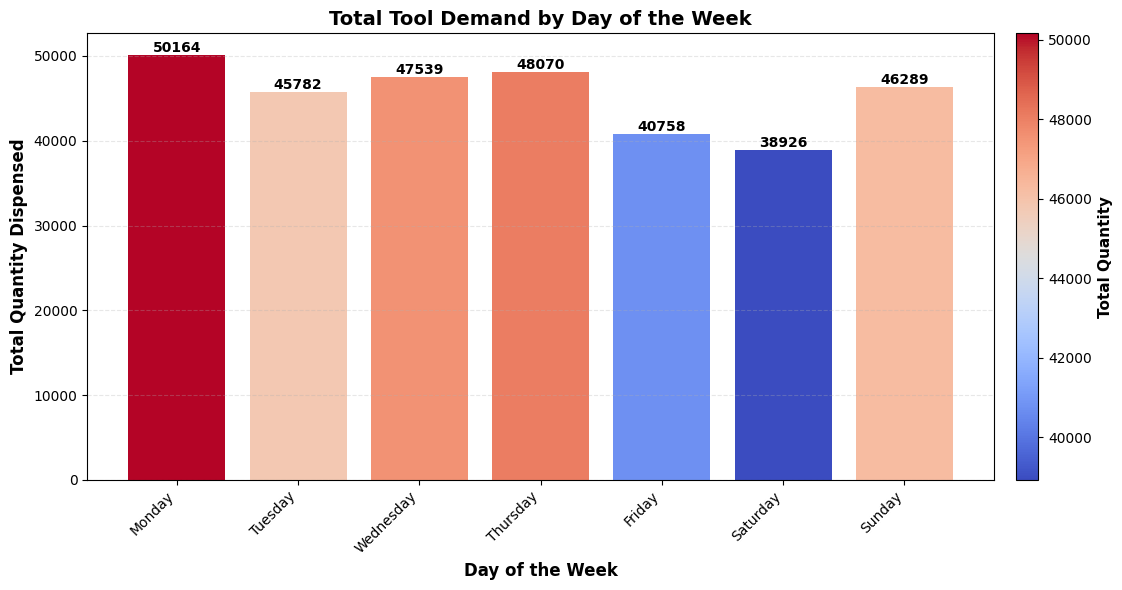

In [23]:
# Resample to Day of the week demand for the whole inventory
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_demand = df_clean_inventory.groupby('day_of_week')['qty_dispensed'].sum().reindex(days_order)

# Normalize values for color mapping (blue = low, red = high)
from matplotlib.colors import Normalize
import matplotlib.cm as cm

norm = Normalize(vmin=weekday_demand.min(), vmax=weekday_demand.max())
cmap = cm.get_cmap('coolwarm')
colors = [cmap(norm(value)) for value in weekday_demand.values]

plt.figure(figsize=(12, 6))
bars = plt.bar(weekday_demand.index, weekday_demand.values, color=colors)

# Add colorbar to show the scale
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
cbar.set_label('Total Quantity', fontsize=11, fontweight='bold')

plt.title('Total Tool Demand by Day of the Week', fontsize=14, fontweight='bold')
plt.ylabel('Total Quantity Dispensed', fontsize=12, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

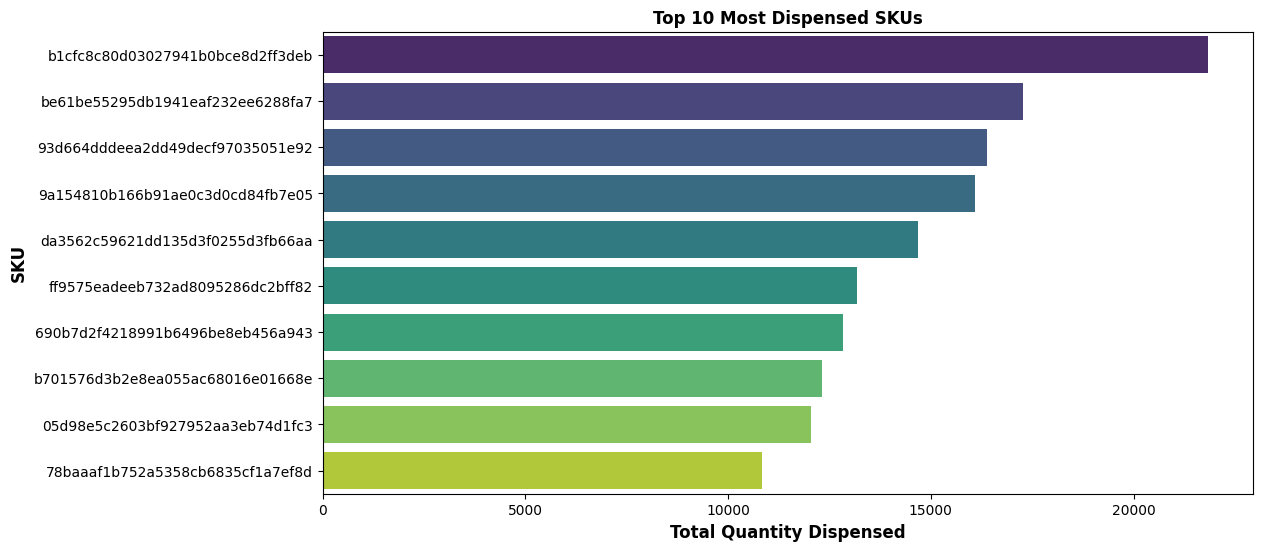

In [31]:
# Group by SKU and sum the quantities dispensed, then sort in descending order
top_sku_summary = daily_inventory.groupby('sku')['qty_dispensed'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_sku_summary.index, x=top_sku_summary.values, palette='viridis', hue=top_sku_summary.index, legend=False)
plt.title('Top 10 Most Dispensed SKUs', fontsize=12, fontweight='bold')
plt.xlabel('Total Quantity Dispensed', fontsize=12, fontweight='bold')
plt.ylabel('SKU', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.show()

To identify which SKUs are truly "problematic," we use a Strategic Inventory Positioning Chart. This plot places every product on a grid based on its average demand (Volume) and its unpredictability (CV).


##How to Read This Chart
The chart is divided into four zones that dictate your inventory strategy:

**Bottom Right (Stable & High Volume)**: These are your "bread and butter" items. They move fast but are very predictable. You can keep low safety stock here.

**Bottom Left (Stable & Low Volume)**: Slow but steady movers. Easy to manage with simple min-max levels.

**Top Left (Erratic & Low Volume)**: "Lumpy" demand. These items aren't used often, but when they are, the amounts vary wildly. Hard to predict, but since volume is low, the cost of error is small.

**Top Right (The "Danger Zone")**: These are your most problematic SKUs. They have high volume AND high unpredictability. If you get the forecast wrong here, you either run out of tools immediately or have thousands of dollars in wasted stock.

##Analysis of Your Specific Data
Based on the code execution, your most "problematic" SKUs (those with both high volume and a CV near or above 0.85) are:

SKU 1fc36e6...: Average Volume: 3.17 | CV: 0.88 (Highly Unpredictable)

SKU d8f674f...: Average Volume: 2.91 | CV: 0.84

Most Unpredictable SKUs:
                                   average_daily_volume   std_dev        cv
sku                                                                       
1fc36e6327e578011358e52fcedfda9a              3.169312  2.810174  0.886683
9d60025d39c34f6d75a0110e3957b79b              1.617391  1.373832  0.849412
d8f674f1baeb28ba583c9c467e67365d              2.911392  2.456380  0.843713
01bdf04bb36dfcd94a9ef6fce31afc59              1.766537  1.292998  0.731940
912562560d2e2e4558eed7feaaf1cba1              3.626230  2.635111  0.726681


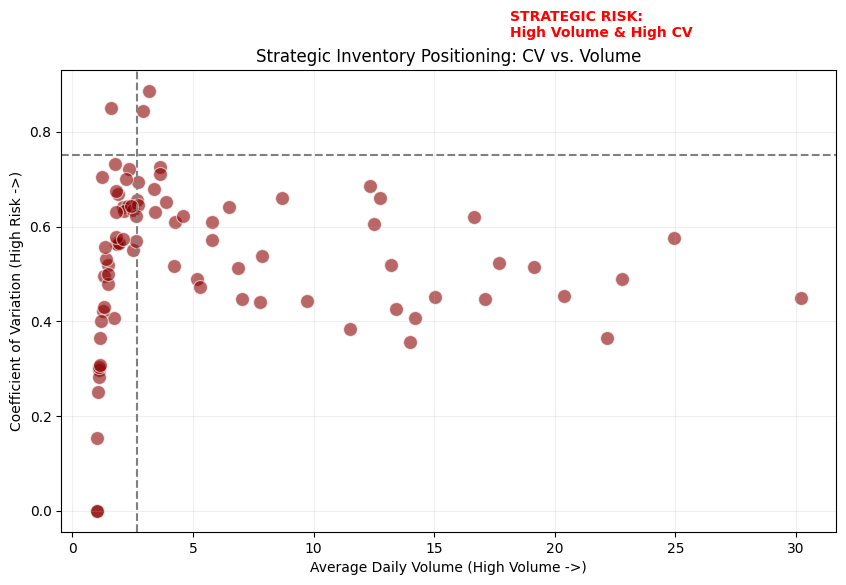

In [34]:
# 1. Aggregate to Daily Demand per SKU
daily_sku_demand = df_clean_inventory.groupby(['dispense_date', 'sku'])['qty_dispensed'].sum().reset_index()

# 2. Calculate Mean Volume and CV (Standard Deviation / Mean)
sku_stats = daily_sku_demand.groupby('sku')['qty_dispensed'].agg(['mean', 'std']).rename(columns={
    'mean': 'average_daily_volume',
    'std': 'std_dev'
})

# Calculate Coefficient of Variation (CV = Std Dev / Mean)
sku_stats['cv'] = sku_stats['std_dev'] / sku_stats['average_daily_volume']

# High CV (> 1.0) means very unpredictable demand
unpredictable_items = sku_stats.sort_values(by='cv', ascending=False).head(5)
print("Most Unpredictable SKUs:\n", unpredictable_items)

# 3. Create the Strategic Inventory Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sku_stats, x='average_daily_volume', y='cv', color='darkred', s=100, alpha=0.6)

# Add reference lines to create quadrants
plt.axhline(y=0.75, color='gray', linestyle='--') # Variability Threshold
plt.axvline(x=sku_stats['average_daily_volume'].median(), color='gray', linestyle='--') # Volume Threshold

plt.title('Strategic Inventory Positioning: CV vs. Volume')
plt.xlabel('Average Daily Volume (High Volume ->)')
plt.ylabel('Coefficient of Variation (High Risk ->)')

# Label the "Danger Zone"
plt.text(sku_stats['average_daily_volume'].max()*0.6, 1.0, "STRATEGIC RISK:\nHigh Volume & High CV", color='red', fontweight='bold')

plt.grid(True, alpha=0.2)
plt.show()

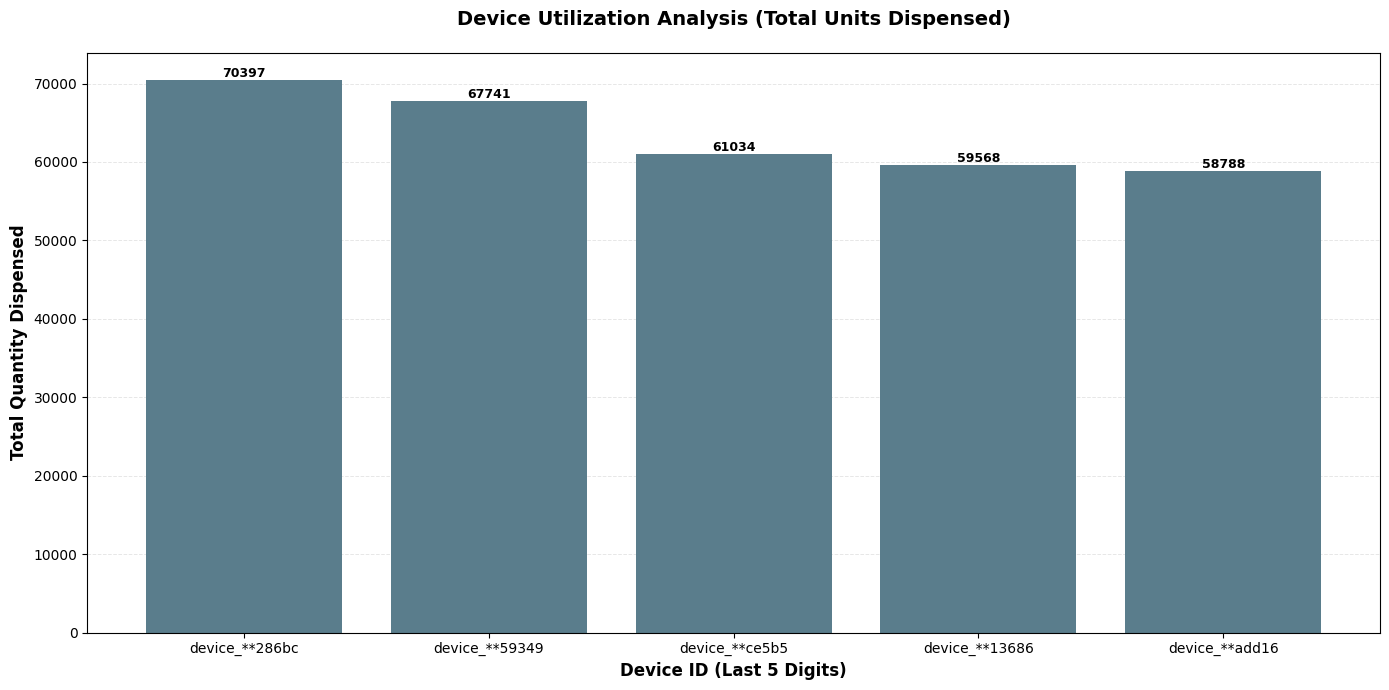


=== DEVICE UTILIZATION REPORT ===
Total Devices: 5
Average Usage per Device: 63505.60 units
Median Usage per Device: 61034.00 units
Highest Performing Device: device_6726f2a054f54836aaabe8c7643286bc (70397 units)
Total Units Dispensed: 317528 units


In [56]:
# Average daily dispenses per device
device_usage = df_clean_inventory.groupby('device_id')['qty_dispensed'].sum().sort_values(ascending=False)

# Create enhanced visualization
plt.figure(figsize=(14, 7))
ax = plt.gca()

# Use a single neutral color for all bars
neutral_color = '#5a7d8c'  # Steel blue-gray

# Plot bars with single neutral color
bars = ax.bar(range(len(device_usage)), device_usage.values, color=neutral_color)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, device_usage.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(value)}',
           ha='center', va='bottom', fontsize=9, fontweight='bold')

# Styling
ax.set_xlabel('Device ID (Last 5 Digits)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Quantity Dispensed', fontsize=12, fontweight='bold')
ax.set_title('Device Utilization Analysis (Total Units Dispensed)', fontsize=14, fontweight='bold', pad=20)

# Set x-axis labels with only last 5 digits of device_id
short_labels = [device_id[-5:] if len(device_id) >= 5 else device_id for device_id in device_usage.index]
ax.set_xticks(range(len(device_usage)))
ax.set_xticklabels((f'device_**{label}' for label in short_labels), ha='center')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n=== DEVICE UTILIZATION REPORT ===")
print(f"Total Devices: {len(device_usage)}")
print(f"Average Usage per Device: {device_usage.mean():.2f} units")
print(f"Median Usage per Device: {device_usage.median():.2f} units")
print(f"Highest Performing Device: {device_usage.index[0]} ({device_usage.values[0]} units)")
print(f"Total Units Dispensed: {device_usage.sum():.0f} units")

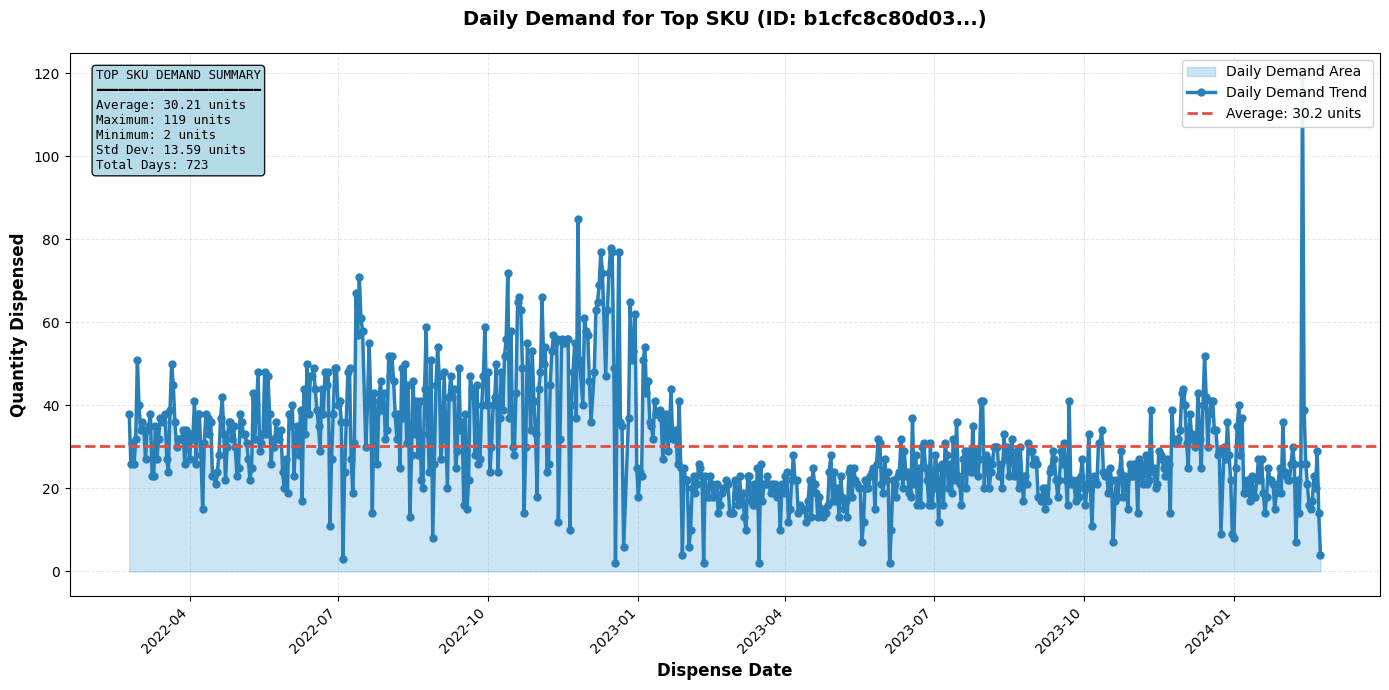


=== TOP SKU DEMAND ANALYSIS ===
SKU ID: b1cfc8c80d03027941b0bce8d2ff3deb
Average Daily Demand: 30.21 units
Maximum Daily Demand: 119 units
Minimum Daily Demand: 2 units
Std Deviation: 13.59 units
Total Observation Days: 723
Trend: Decreasing


In [63]:
# Plot daily demand for top SKU ID
top_sku = df_clean_inventory.groupby('sku')['qty_dispensed'].sum().idxmax()
top_sku_data = df_clean_inventory[df_clean_inventory['sku'] == top_sku].copy()
daily_demand = top_sku_data.groupby('dispense_date')['qty_dispensed'].sum().sort_index()

# Calculate statistics
avg_demand = daily_demand.mean()
max_demand = daily_demand.max()
min_demand = daily_demand.min()
std_demand = daily_demand.std()

# Create enhanced visualization
plt.figure(figsize=(14, 7))
ax = plt.gca()

# Add fill area
ax.fill_between(daily_demand.index, daily_demand.values, alpha=0.25, color='#3498db', label='Daily Demand Area')

# Plot line with markers
ax.plot(daily_demand.index, daily_demand.values, marker='o', linewidth=2.5, markersize=5, 
        color='#2980b9', label='Daily Demand Trend')

# Add reference line for average
ax.axhline(y=avg_demand, color='#e74c3c', linestyle='--', linewidth=2, 
          label=f'Average: {avg_demand:.1f} units')

# Styling
ax.set_xlabel('Dispense Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantity Dispensed', fontsize=12, fontweight='bold')
ax.set_title(f'Daily Demand for Top SKU (ID: {top_sku[:12]}...)', fontsize=14, fontweight='bold', pad=20)

# Grid improvements
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add floating statistics box
stats_text = f"""TOP SKU DEMAND SUMMARY
━━━━━━━━━━━━━━━━━━━━━━
Average: {avg_demand:.2f} units
Maximum: {max_demand:.0f} units
Minimum: {min_demand:.0f} units
Std Dev: {std_demand:.2f} units
Total Days: {len(daily_demand)}"""

ax.text(0.02, 0.97, stats_text, transform=ax.transAxes,
       fontsize=9, verticalalignment='top', horizontalalignment='left',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9),
       family='monospace')

# Add legend
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\n=== TOP SKU DEMAND ANALYSIS ===")
print(f"SKU ID: {top_sku}")
print(f"Average Daily Demand: {avg_demand:.2f} units")
print(f"Maximum Daily Demand: {max_demand:.0f} units")
print(f"Minimum Daily Demand: {min_demand:.0f} units")
print(f"Std Deviation: {std_demand:.2f} units")
print(f"Total Observation Days: {len(daily_demand)}")
print(f"Trend: {'Increasing' if daily_demand.iloc[-1] > daily_demand.iloc[0] else 'Decreasing'}")


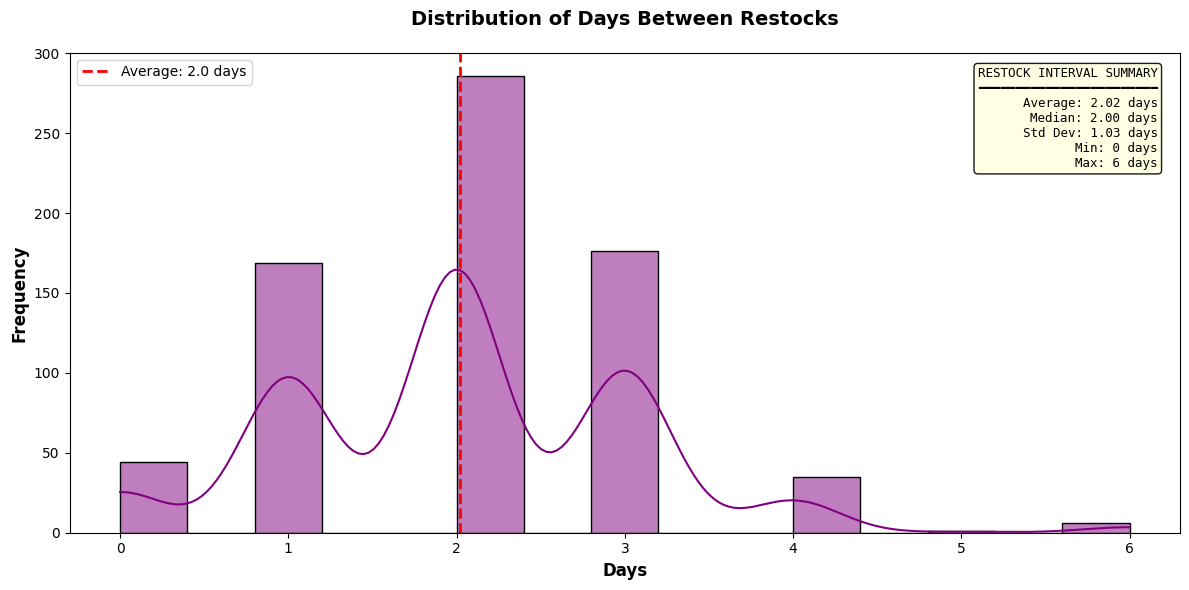


=== RESTOCK INTERVAL ANALYSIS ===
Average Restock Interval: 2.02 days
Median Restock Interval: 2.00 days
Std Dev: 1.03 days
Min Interval: 0 days
Max Interval: 6 days


In [58]:
# Restock Frequency (Lead Time Analysis)

# Sort by device and date, then calculate the gap between restocks
restock = df_clean_restock.sort_values(['device_id', 'restock_date'])
restock['days_between_restocks'] = restock.groupby('device_id')['restock_date'].diff().dt.days

# Calculate statistics
restock_data = restock['days_between_restocks'].dropna()
avg_interval = restock_data.mean()
median_interval = restock_data.median()
min_interval = restock_data.min()
max_interval = restock_data.max()
std_interval = restock_data.std()

# Create histogram
plt.figure(figsize=(12, 6))
ax = plt.gca()
sns.histplot(restock_data, bins=15, kde=True, color='purple', ax=ax)

# Add title and labels
plt.title('Distribution of Days Between Restocks', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Days', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')

# Add a vertical line for the average
ax.axvline(avg_interval, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_interval:.1f} days')
ax.legend(fontsize=10)

# Add floating statistics box
stats_text = f"""RESTOCK INTERVAL SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━
Average: {avg_interval:.2f} days
Median: {median_interval:.2f} days
Std Dev: {std_interval:.2f} days
Min: {min_interval:.0f} days
Max: {max_interval:.0f} days"""

ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
       fontsize=9, verticalalignment='top', horizontalalignment='right',
       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9),
       family='monospace')

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\n=== RESTOCK INTERVAL ANALYSIS ===")
print(f"Average Restock Interval: {avg_interval:.2f} days")
print(f"Median Restock Interval: {median_interval:.2f} days")
print(f"Std Dev: {std_interval:.2f} days")
print(f"Min Interval: {min_interval:.0f} days")
print(f"Max Interval: {max_interval:.0f} days")

In [ ]:
# Phase 3: Feature Engineering

## Overview
Feature engineering is the process of transforming raw data into meaningful features that improve machine learning model performance. In Phase 3, we prepare our inventory data for predictive modeling by creating structured features from temporal and demand patterns.

## Why Phase 3 is Critical

### Problem We're Solving
Raw time-series data (date + quantity dispensed) cannot be directly fed into machine learning models. Models need numerical features that capture:
- **Temporal patterns** (when demand occurs)
- **Historical context** (past demand influences future demand)
- **Demand trends** (moving averages reveal patterns)

Without feature engineering, the model would have no way to learn demand seasonality or momentum.

---

## Phase 3 Tasks Breakdown

### 1. **Aggregate to Daily Level (SKU + Device)**
- **Purpose**: Convert transaction-level data (multiple rows per day) into daily summaries
- **Method**: Group by `dispense_date`, `sku`, and `device_id`, then sum `qty_dispensed`
- **Output**: One row per SKU-Device-Date combination with total daily quantity
- **Why**: Eliminates multiple transactions on the same day, creating consistent time intervals for modeling

### 2. **Add Calendar Features**
- **Month**: Extract month from `dispense_date` (1-12) to capture seasonal demand patterns
- **Day of Week**: Convert date to numeric day (0=Monday, 6=Sunday) for weekly seasonality
- **Is Weekend**: Binary flag (1 if Saturday/Sunday, 0 otherwise) to detect weekend demand spikes
- **Benefits**: These features help the model learn cyclical patterns (e.g., higher demand on weekends)

### 3. **Add Lag Features (Historical Context)**
- **Lag 1**: Yesterday's demand for the same SKU-Device combination
- **Lag 7**: Demand from 7 days ago (captures weekly seasonal effects)
- **Importance**: Models learn that past demand is often predictive of future demand
- **Critical**: Grouped by `sku` and `device_id` to avoid mixing different products' history

### 4. **Add Rolling Features (Trend Analysis)**
- **Rolling Mean (7-day)**: Calculate the moving average of quantity dispensed over the last 7 days
- **Purpose**: Smooths out daily fluctuations and reveals underlying demand trends
- **Calculation**: Applied per SKU-Device group to maintain data integrity
- **Benefit**: Helps distinguish between temporary spikes and sustained demand changes

### 5. **Clean Up NaN Values**
- **Issue**: Lag and rolling features create NaN values at the beginning of each time series
- **Action**: Drop all rows with missing values using `.dropna()`
- **Result**: `df_model_ready` is ready for machine learning model training
- **Trade-off**: Losing first few data points ensures model receives complete, valid feature sets

In [64]:
# 1. Aggregate to Daily Level (SKU + Device)
df_daily = df_clean_inventory.groupby(['dispense_date', 'sku', 'device_id'])['qty_dispensed'].sum().reset_index()
df_daily = df_daily.sort_values(['sku', 'device_id', 'dispense_date'])

# 2. Add Calendar Features
df_daily['month'] = df_daily['dispense_date'].dt.month
df_daily['day_of_week'] = df_daily['dispense_date'].dt.dayofweek
df_daily['is_weekend'] = df_daily['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# 3. Add Lag Features (Important: Group by SKU and Device so we don't mix products)
df_daily['lag_1'] = df_daily.groupby(['sku', 'device_id'])['qty_dispensed'].shift(1)
df_daily['lag_7'] = df_daily.groupby(['sku', 'device_id'])['qty_dispensed'].shift(7)

# 4. Add Rolling Features (7-day Average)
df_daily['rolling_mean_7'] = df_daily.groupby(['sku', 'device_id'])['qty_dispensed'].transform(lambda x: x.rolling(window=7).mean())

# 5. Clean up the resulting NaNs (from the lags)
df_model_ready = df_daily.dropna()

print("Features Generated successfully!")
display(df_model_ready.head(20))

Features Generated successfully!


,dispense_date,sku,device_id,qty_dispensed,month,day_of_week,is_weekend,lag_1,lag_7,rolling_mean_7
812,2022-03-09,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,1,3,2,0,2.0,1.0,2.428571
868,2022-03-10,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,3,3,3,0,1.0,1.0,2.714286
920,2022-03-11,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,5,3,4,0,3.0,2.0,3.142857
970,2022-03-12,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,4,3,5,1,5.0,4.0,3.142857
1020,2022-03-13,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,4,3,6,1,4.0,6.0,2.857143
1070,2022-03-14,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,1,3,0,0,4.0,1.0,2.857143
1132,2022-03-15,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,1,3,1,0,1.0,2.0,2.714286
1248,2022-03-17,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,5,3,3,0,1.0,1.0,3.285714
1303,2022-03-18,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,3,3,4,0,5.0,3.0,3.285714
1362,2022-03-19,01bdf04bb36dfcd94a9ef6fce31afc59,device_65ae7ea424c57d46ac409256fe359349,5,3,5,1,3.0,5.0,3.285714


In [ ]:
# Phase 4: Predictive Modeling & Demand Forecasting

## Overview
Phase 4 transforms engineered features into actionable demand forecasts using machine learning. This phase builds a predictive model that can anticipate future inventory needs, enabling proactive restocking decisions and reducing stockout risks.

## Why Phase 4 is Critical

### The Problem We're Solving
**Manual restocking is reactive and inefficient:**
- Restocking decisions are often based on gut feelings or simple min-max rules
- This leads to either stockouts (lost sales, customer dissatisfaction) or overstocking (wasted capital, expired inventory)
- Without forecasts, you can't optimize lead times or safety stock levels

**Predictive modeling solves this by:**
- Learning complex demand patterns from historical data
- Forecasting future demand with quantifiable accuracy
- Enabling data-driven inventory optimization
- Reducing both stockout costs and holding costs

### Key Business Benefits
✓ **Prevent Stockouts**: Anticipate demand spikes before they happen  
✓ **Reduce Waste**: Avoid over-ordering slow-moving items  
✓ **Optimize Restocking**: Know exactly when and how much to reorder  
✓ **Cost Savings**: Lower inventory carrying costs + fewer emergency restocks  
✓ **Scalability**: Automate forecasting across hundreds of SKUs and devices  

---

## Phase 4 Tasks Breakdown

### Task 1: Feature Selection & Data Preparation

**What We Do:**
- Identify which features (predictors) the model will use
- Split data into training and testing sets using **chronological order** (not random)

**Features Used:**
| Feature | Purpose |
|---------|---------|
| `month` | Captures seasonal demand (e.g., higher in winter) |
| `day_of_week` | Identifies weekly patterns (weekdays vs. weekends) |
| `is_weekend` | Binary flag for weekend demand spikes |
| `lag_1` | Yesterday's demand (momentum indicator) |
| `lag_7` | Demand from 7 days ago (weekly seasonality) |
| `rolling_mean_7` | 7-day average (trend smoothing) |

**Target Variable:**
- `qty_dispensed`: The quantity we want to predict

**Why Chronological Split:**

Mean Absolute Error: 3.37 units


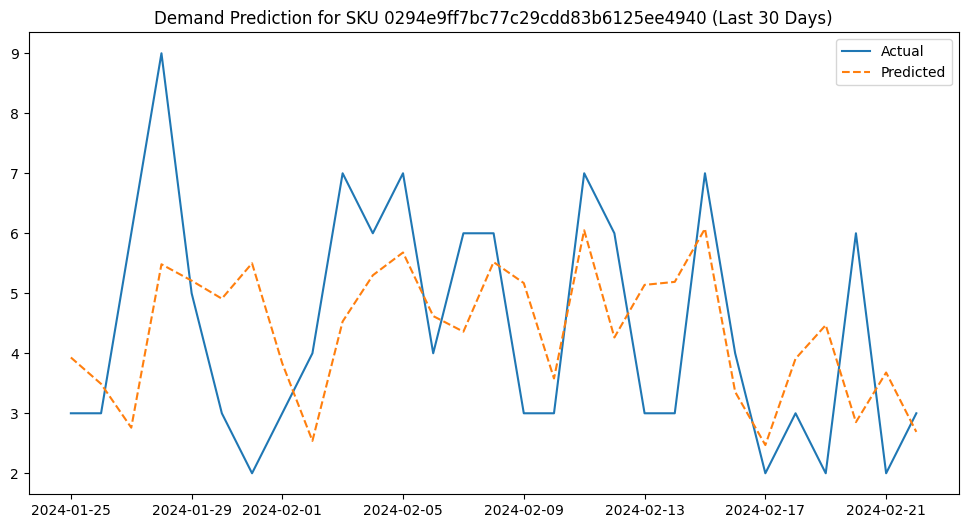

In [90]:

# 1. Prepare Features & Target
# Ensure you have already run the Phase 3 code to get 'df_model_ready'
features = ['month', 'day_of_week', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7']
target = 'qty_dispensed'

# 2. Chronological Split (Last 30 days for testing)
split_date = df_model_ready['dispense_date'].max() - pd.Timedelta(days=30)
train = df_model_ready[df_model_ready['dispense_date'] <= split_date]
test = df_model_ready[df_model_ready['dispense_date'] > split_date]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 3. Build & Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f} units")

# 5. Visualizing for a specific SKU
# Choose one SKU and plot its actual vs predicted values

sample_sku = test[test['sku'] == test['sku'].iloc[10]]  # Change index to select different SKU
plt.figure(figsize=(12, 6))
plt.plot(sample_sku['dispense_date'], sample_sku['qty_dispensed'], label='Actual')
plt.plot(sample_sku['dispense_date'], model.predict(sample_sku[features]), label='Predicted', linestyle='--')
plt.legend()
plt.title(f'Demand Prediction for SKU {sample_sku["sku"].iloc[0]} (Last 30 Days)')
plt.show()


In [91]:
# Phase 5: Inventory Optimization Recommendations
# 1. Calculate SKU-level demand statistics
daily_sku_demand = df_clean_inventory.groupby(['dispense_date', 'sku'])['qty_dispensed'].sum().reset_index()
sku_stats = daily_sku_demand.groupby('sku')['qty_dispensed'].agg(['mean', 'std']).rename(columns={
    'mean': 'avg_daily_demand',
    'std': 'std_dev_demand'
}).fillna(0)

# 2. Optimization Parameters
lead_time = 3 # Assumed 3-day lead time
service_level = 1.65 # 95% service level

# 3. Calculate Safety Stock & Reorder Point
sku_stats['safety_stock'] = np.ceil(service_level * sku_stats['std_dev_demand'] * np.sqrt(lead_time))
sku_stats['reorder_point'] = np.ceil((sku_stats['avg_daily_demand'] * lead_time) + sku_stats['safety_stock'])

# 4. Final Recommendation Table for your Report
optimization_report = sku_stats.sort_values(by='avg_daily_demand', ascending=False).head(20)
print("--- INDUSTRIAL VENDING OPTIMIZATION REPORT ---")
display(optimization_report[['avg_daily_demand', 'safety_stock', 'reorder_point']])

--- INDUSTRIAL VENDING OPTIMIZATION REPORT ---


,avg_daily_demand,safety_stock,reorder_point
sku,,,
b1cfc8c80d03027941b0bce8d2ff3deb,30.214385,39.0,130.0
be61be55295db1941eaf232ee6288fa7,24.960983,42.0,117.0
93d664dddeea2dd49decf97035051e92,22.802503,32.0,101.0
9a154810b166b91ae0c3d0cd84fb7e05,22.183448,24.0,91.0
da3562c59621dd135d3f0255d3fb66aa,20.393056,27.0,89.0
ff9575eadeeb732ad8095286dc2bff82,19.138081,29.0,87.0
690b7d2f4218991b6496be8eb456a943,17.670799,27.0,81.0
b701576d3b2e8ea055ac68016e01668e,17.093056,22.0,74.0
05d98e5c2603bf927952aa3eb74d1fc3,16.646409,30.0,80.0


                                         Daily_Demand  Restock_Frequency_Days
device_id                                                                    
device_0749c361d8ac7047c2f98fbcb2eadd16     11.270706                2.108696
device_65ae7ea424c57d46ac409256fe359349      7.985500                2.070922
device_6726f2a054f54836aaabe8c7643286bc      9.332759                2.049645
device_af645ebf4c96eb6e430529a2a9913686      6.592297                1.965986
device_c287be7e02167387bf9e7eca061ce5b5      7.012178                1.926667


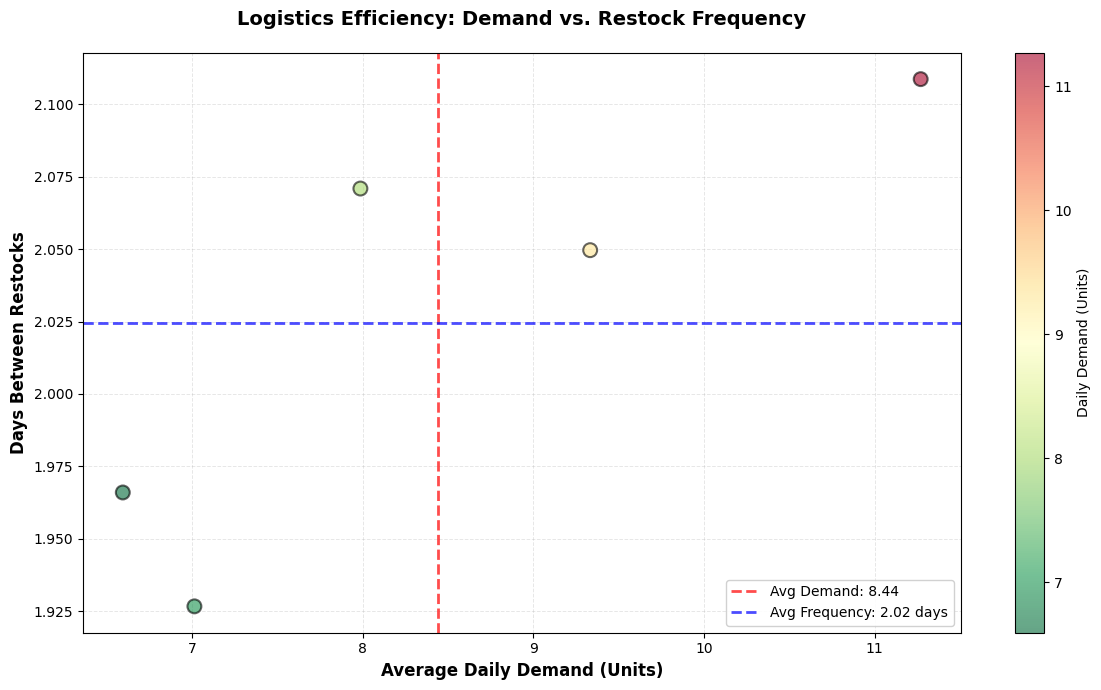


=== LOGISTICS EFFICIENCY SUMMARY ===
Total Devices: 5
Average Daily Demand: 8.44 units
Average Restock Frequency: 2.02 days
Demand Range: 6.59 - 11.27 units
Frequency Range: 1.93 - 2.11 days


In [99]:
# 1. Calculate Average Daily Demand per Device (Inventory Data)
device_demand = df_clean_inventory.groupby('device_id')['qty_dispensed'].mean()

# 2. Calculate Average Days Between Restocks (Restock Data)
restock = restock.sort_values(['device_id', 'restock_date'])
restock['interval'] = restock.groupby('device_id')['restock_date'].diff().dt.days
avg_intervals = restock.groupby('device_id')['interval'].mean()

# 3. Join the data
restock_analysis = pd.DataFrame({
    'Daily_Demand': device_demand,
    'Restock_Frequency_Days': avg_intervals
}).dropna()

print(restock_analysis.head())

# 4. Enhanced Visualization
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Create scatter plot with color gradient based on daily demand
scatter = ax.scatter(restock_analysis['Daily_Demand'], 
                     restock_analysis['Restock_Frequency_Days'], 
                     c=restock_analysis['Daily_Demand'],
                     cmap='RdYlGn_r',
                     s=100,
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=1.5)

# Add average lines
avg_demand = restock_analysis['Daily_Demand'].mean()
avg_frequency = restock_analysis['Restock_Frequency_Days'].mean()

ax.axvline(x=avg_demand, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Avg Demand: {avg_demand:.2f}')
ax.axhline(y=avg_frequency, color='blue', linestyle='--', linewidth=2, alpha=0.7, label=f'Avg Frequency: {avg_frequency:.2f} days')

# Styling
ax.set_xlabel('Average Daily Demand (Units)', fontsize=12, fontweight='bold')
ax.set_ylabel('Days Between Restocks', fontsize=12, fontweight='bold')
ax.set_title('Logistics Efficiency: Demand vs. Restock Frequency', fontsize=14, fontweight='bold', pad=20)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Daily Demand (Units)')

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

# Add legend
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== LOGISTICS EFFICIENCY SUMMARY ===")
print(f"Total Devices: {len(restock_analysis)}")
print(f"Average Daily Demand: {avg_demand:.2f} units")
print(f"Average Restock Frequency: {avg_frequency:.2f} days")
print(f"Demand Range: {restock_analysis['Daily_Demand'].min():.2f} - {restock_analysis['Daily_Demand'].max():.2f} units")
print(f"Frequency Range: {restock_analysis['Restock_Frequency_Days'].min():.2f} - {restock_analysis['Restock_Frequency_Days'].max():.2f} days")

In [95]:
# 1. Calculate Average Daily Demand per Device
device_demand = df_clean_inventory.groupby('device_id')['qty_dispensed'].agg(['sum', 'mean'])
device_demand.columns = ['Total_Sold', 'Daily_Avg']

# 2. Calculate Restock Frequency (Average days between visits)
restock = restock.sort_values(['device_id', 'restock_date'])
restock['visit_gap'] = restock.groupby('device_id')['restock_date'].diff().dt.days
visit_stats = restock.groupby('device_id').agg({'visit_gap': 'mean', 'global_order_id': 'count'})
visit_stats.columns = ['Avg_Visit_Interval', 'Total_Visits']

# 3. Join and Calculate "Supply Health"
logistics_report = device_demand.join(visit_stats)
logistics_report['Days_of_Supply'] = (logistics_report['Total_Sold'] / logistics_report['Total_Visits']) / logistics_report['Daily_Avg']

# 4. Generate Strategic Recommendations
def set_recommendation(row):
    if row['Days_of_Supply'] > 28 and row['Avg_Visit_Interval'] < 5:
        return "Change to Bi-Weekly (Every 14 Days)"
    elif row['Days_of_Supply'] > 14 and row['Avg_Visit_Interval'] < 4:
        return "Change to Weekly (Every 7 Days)"
    return "Keep Current Schedule"

logistics_report['Strategy'] = logistics_report.apply(set_recommendation, axis=1)

# Display final 10 recommendations
display(logistics_report[['Daily_Avg', 'Avg_Visit_Interval', 'Days_of_Supply', 'Strategy']].head(20))

,Daily_Avg,Avg_Visit_Interval,Days_of_Supply,Strategy
device_id,,,,
device_0749c361d8ac7047c2f98fbcb2eadd16,11.270706,2.108696,37.525180,Change to Bi-Weekly (Every 14 Days)
device_65ae7ea424c57d46ac409256fe359349,7.985500,2.070922,59.739437,Change to Bi-Weekly (Every 14 Days)
device_6726f2a054f54836aaabe8c7643286bc,9.332759,2.049645,53.119718,Change to Bi-Weekly (Every 14 Days)
device_af645ebf4c96eb6e430529a2a9913686,6.592297,1.965986,61.054054,Change to Bi-Weekly (Every 14 Days)
device_c287be7e02167387bf9e7eca061ce5b5,7.012178,1.926667,57.642384,Change to Bi-Weekly (Every 14 Days)
